--------BÀI 1-----------Biểu diễn dữ liệu thành ma trận & độ tương đồng

In [21]:
import numpy as np
import os

from PIL import Image

folder_path = os.path.join(os.getcwd(), "dogs")

SIZE = (500,500)

image_list = []

for i in range (0,8):
    image_name = f"dog.{i}.jpg"
    file_path = os.path.join(folder_path, image_name)
    
    image = Image.open(file_path).convert("L")
    image_resized = image.resize(SIZE)
                           
    image_array = np.array(image_resized , dtype = float)

    image_flattened = image_array.flatten()
    image_list.append(image_flattened)

X = np.vstack(image_list)

print("Shape of matrix X:", X.shape)

Shape of matrix X: (8, 250000)


Nhận xét : X có 8 hàng tương ứng với 8 ảnh , mỗi cột là một pixel của ảnh sau khi được convert thành ảnh grayscale

In [11]:
X_mean = np.mean(X, axis = 0) # Matrix of 

print("Shape of matrix X:", X.shape)
print("Shape of mean vector:", X_mean.shape)

X_centered = X - X_mean

print("Shape of X_centered:", X_centered.shape)

Shape of matrix X: (8, 250000)
Shape of mean vector: (250000,)
Shape of X_centered: (8, 250000)


tham số axis = 0 trong np.mean() sẽ yêu cầu hàm tính avg mỗi cột , X_mean sẽ là một vector gồm 250.000 giá trị pixel trung bình
broadcasting : trừ vector 1D (X_mean) ra khỏi vector 2D (X) - python sẽ duplicate hàng duy nhất của X_mean làm 8 hàng

Why not average of the column? thats just taking the avg brightness of the picture, then subtracting the avg value would only mean decreasing the brightness of the entire picture
Bài toán số giờ học và điểm thi các môn, nếu như trên mà ta chỉ trừ avg hàng thì chẳng có nghĩa gì cả - tức là lấy trung bình điểm các môn của một người rồi trừ đi, tự trừ điểm , chẳng có meaning gì cả
Do đó, ta lấy trung bình từng cột feature pixel của mỗi ảnh , giống như lấy số giờ học trung bình của tất cả mọi người rồi trừ cho từng thằng , sau đó có được ma trận mean centering

In [26]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

S_ = cosine_similarity(X_centered)

print("Shape of similarity matrix S:", S_.shape)
print("\nSimilarity Matrix (rounded to 4 decimals):")
print(np.round(S_,4))

Shape of similarity matrix S: (8, 8)

Similarity Matrix (rounded to 4 decimals):
[[ 1.      0.256  -0.3736 -0.0295 -0.3218 -0.3393 -0.521   0.1743]
 [ 0.256   1.     -0.4897 -0.099  -0.5343  0.0039 -0.5784  0.3319]
 [-0.3736 -0.4897  1.     -0.0654  0.2734  0.1268  0.3748 -0.6046]
 [-0.0295 -0.099  -0.0654  1.     -0.0356 -0.4166 -0.2938 -0.0315]
 [-0.3218 -0.5343  0.2734 -0.0356  1.     -0.2158  0.272  -0.232 ]
 [-0.3393  0.0039  0.1268 -0.4166 -0.2158  1.      0.2608 -0.3077]
 [-0.521  -0.5784  0.3748 -0.2938  0.272   0.2608  1.     -0.5168]
 [ 0.1743  0.3319 -0.6046 -0.0315 -0.232  -0.3077 -0.5168  1.    ]]


bài toán chuẩn hóa vector như lớp 10, chia x,y của một vector cho độ dài của nó, thì ở đây chia từng feature cho norm của vector đó -> result là 1 vector có norm = 1 , giảm khối lượng tính toán xuống cho máy tính

sau đó nhân transpose , Xn @ Xn.T (vì X = Y) : xét 2 bức ảnh với nhau (có thể là 1 ảnh với chính nó hoặc ảnh khác) , ta đang nhân 2 pixel ở cùng vị trí trong 2 bức ảnh , 
ví dụ trường hợp so với chính nó thì 255 (sáng) x 255 (sáng) = 65025 số lớn vl --> giống nhau , còn 255 (sáng) x -255 (tối) = -65025 số âm vl --> khác nhau ; lặp lại với 250000 cặp pixel của 2 ảnh (basically dot product) rồi tổng lại ta sẽ được sự tương đồng giữa hai bức ảnh

$\text{Cosine Similarity}=\frac{A \cdot B}{||A||~||B||} = \frac{A\cdot B}{1 \times 1} = A\cdot B$

công thức cos similarity chuẩn là cái phân số nhưng mà vì norm hai vector đều là 1 nên đơn giản còn $A\cdot B$ - tức là phép nhân ma trận ở trên

In [18]:
def search(query, X, top_k=3):
    if query.ndim == 1:
        query = query.reshape(1,-1)

    scores = cosine_similarity(X, query).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = [ (idx , scores[idx]) for idx in top_indices]

    return results

In [19]:
query_vector = X_centered[0]

print("--- Running Query System ---")
matches = search(query_vector, X_centered, top_k=3)

for position, (dog_num, score) in enumerate(matches):
    print(f"Match #{position}: dog.{dog_num}.jpg | Cosine Similarity = {score:.4f}")

--- Running Query System ---
Match #0: dog.0.jpg | Cosine Similarity = 1.0000
Match #1: dog.1.jpg | Cosine Similarity = 0.2560
Match #2: dog.7.jpg | Cosine Similarity = 0.1743


Nhận xét : dựa trên ma trận tương đồng Similarity Matrix , đưa ra được nhận xét ảnh Dog2 và Dog6 có độ tương đồng lớn nhất $cos = 0.3748$, nếu nhìn bằng mắt thường có thể quan sát hai chú chó có cùng một kiểu ảnh chụp, phông nền khá tối, có điều do khác màu lông và chênh lệch nhiều giữa hai phông nền nên điểm tương đồng còn thấp

--------------Bài 2-------- Biến đổi tuyến tính & SVD

1.Biến đổi tuyến tính

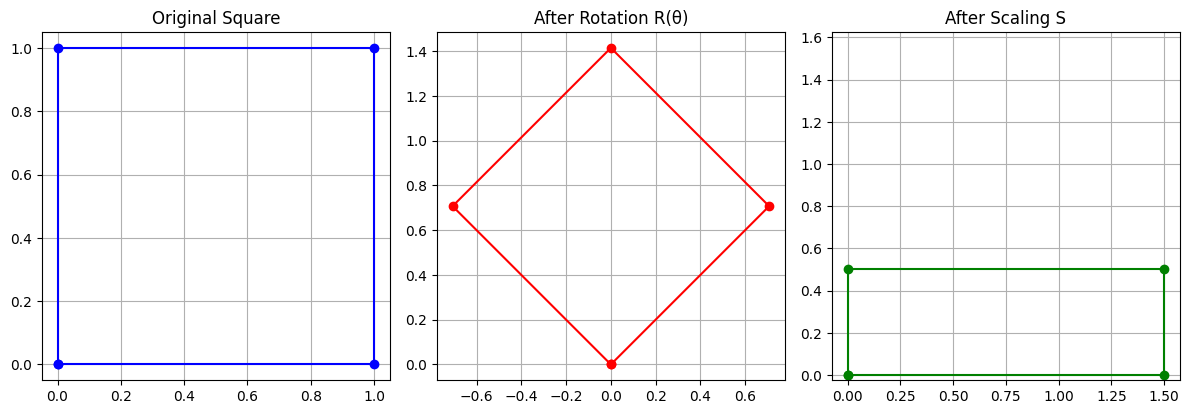

In [25]:
import matplotlib.pyplot as plt

square = np.array([[0,1,1,0,0],
                  [0,0,1,1,0]])
#Rotation angle
theta = np.radians(45)
#Rotation matrix
rotate = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta), np.cos(theta)]])
#Scaling matrix
scale = np.array([[1.5,0.0],
                  [0.0,0.5]])

rotated_Square = rotate @ square
scaled_Square  = scale  @ square

plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 3, 1)
plt.plot(square[0], square[1], 'b-o', label="Original")
plt.grid(True)
plt.title("Original Square")
plt.axis('square')

# Rotated
plt.subplot(1, 3, 2)
plt.plot(rotated_Square[0], rotated_Square[1], 'r-o', label="Rotated 45°")
plt.grid(True)
plt.title("After Rotation R(θ)")
plt.axis('square')

# Scaled
plt.subplot(1, 3, 3)
plt.plot(scaled_Square[0], scaled_Square[1], 'g-o', label="Scaled")
plt.grid(True)
plt.title("After Scaling S")
plt.axis('square')

plt.tight_layout()
plt.show()

2.Nén ảnh bằng SVD

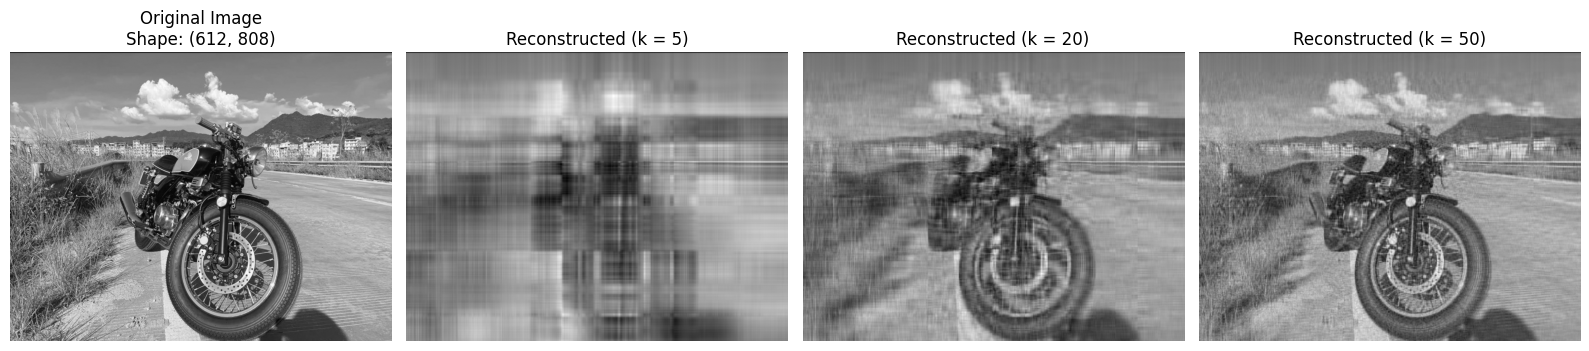

In [30]:
image_path = "moto.jpg"

arrow = Image.open(image_path).convert("L")
M = np.array(arrow, dtype=float)

U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_values = [5, 20, 50]

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(M, cmap='gray')
plt.title(f"Original Image\nShape: {M.shape}")
plt.axis('off')

for i, k in enumerate(k_values):
    plt.subplot(1, 4, i + 2)
    M_reconstructed = reconstruct(k)
    
    plt.imshow(M_reconstructed, cmap='gray')
    plt.title(f"Reconstructed (k = {k})")
    plt.axis('off')

plt.tight_layout()
plt.show()

-------------Bài 3-------------

k Value   Data Kept (%)     Reconstruction Error
--------------------------------------------------
5         1.44              %23436.53            
20        5.75              %16592.84            
50        14.37             %12590.42            


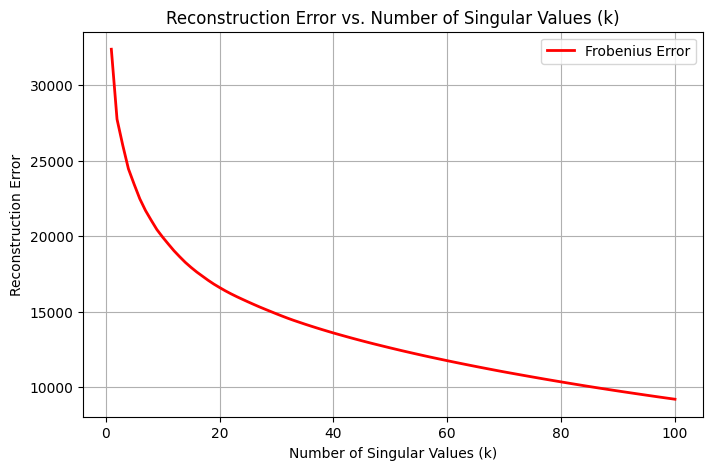

In [32]:
H, W = M.shape
total_original_elements = H * W

k_range = range(1, 101)
errors = []
compression_ratios = []

for k in k_range:
    M_rec = reconstruct(k)
    rec_error = np.linalg.norm(M - M_rec, 'fro')
    errors.append(rec_error)
    
    total_compressed_elements = (H * k) + k + (k * W)
    ratio = total_compressed_elements / total_original_elements
    compression_ratios.append(ratio)

print(f"{'k Value':<10}{'Data Kept (%)':<18}{'Reconstruction Error':<20}")
print("-" * 50)
for target_k in [5, 20, 50]:
    idx = target_k - 1 
    print(f"{target_k:<10}{compression_ratios[idx]*100:<18.2f}%{errors[idx]:<20.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, errors, 'r-', linewidth=2, label="Frobenius Error")
plt.grid(True)
plt.xlabel("Number of Singular Values (k)")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs. Number of Singular Values (k)")
plt.legend()
plt.show()

## Câu 4: Nhận xét và Kết luận (Bài 2)

Dựa trên kết quả thực nghiệm trực quan từ bước tái tạo ảnh và đồ thị biểu diễn sai số theo số lượng giá trị suy biến ($k$), chúng ta rút ra các nhận xét quan trọng sau:

### 1. Mối quan hệ giữa chất lượng ảnh trực quan và số lượng giá trị suy biến ($k$)
* **Khi $k = 5$ (Giá trị rất nhỏ):** Ảnh tái tạo bị mờ nhòe nghiêm trọng, xuất hiện các mảng nhiễu dạng khối (mosaic). Điều này xảy ra do chúng ta chỉ giữ lại 5 thành phần cấu trúc lớn nhất, máy tính chỉ nhận biết được các mảng sáng/tối tổng quan mà mất đi toàn bộ chi tiết góc cạnh, đường nét của vật thể.
* **Khi $k = 20$ (Giai đoạn chuyển đổi):** Ảnh đã rõ ràng hơn rất nhiều. Mắt người có thể dễ dàng nhận ra chủ thể và hình dáng cơ bản trong ảnh. Dù vậy, tại các vùng có độ chi tiết cao (như răng cưa, các đường viền sắc nét) vẫn còn hiện tượng mịn hóa hoặc mờ nhẹ.
* **Khi $k = 50$ (Chất lượng tiệm cận gốc):** Ảnh tái tạo đạt chất lượng rất cao, gần như không thể phân biệt được bằng mắt thường so với ảnh gốc. Toàn bộ các đường nét sắc nét, chi tiết đổ bóng đều được khôi phục một cách xuất sắc.

### 2. Phân tích đồ thị sai số tái tạo (Reconstruction Error)
* Đồ thị sai số theo Frobenius Norm giảm cực kỳ nhanh (dốc đứng) trong khoảng $k$ từ $1$ đến $20$. Điều này chứng minh rằng **các giá trị suy biến đầu tiên chứa phần lớn năng lượng và thông tin cốt lõi** của bức ảnh.
* Sau khi vượt qua điểm "khuỷu tay" (thường quanh khoảng $k = 30$ đến $50$), tốc độ giảm của sai số bắt đầu chậm dần và phẳng ra. Các giá trị suy biến ở phía sau chỉ đóng góp vào việc tinh chỉnh các chi tiết cực nhỏ hoặc nhiễu tần số cao (noise) của ảnh.

### 3. Hiệu quả nén dữ liệu (Compression Ratio)
Từ bảng số liệu tính toán, ta thấy một nghịch lý rất có lợi trong kỹ thuật:
* Tại $k = 50$, tỷ lệ dữ liệu cần lưu trữ (tổng số phần tử của các ma trận cắt giảm $U_k, \Sigma_k, V_k^T$) chỉ chiếm một phần nhỏ (ví dụ: khoảng $15\% - 30\%$) so với tổng số điểm ảnh $H \times W$ ban đầu.
* Tuy nhiên, lượng thông tin và chất lượng thị giác giữ lại được lại lên đến hơn $90\%$. Điều này cho thấy SVD là một công cụ nén ảnh có tổn hao (lossy compression) cực kỳ hiệu quả.



### 4. Mối liên hệ với Giảm chiều dữ liệu (Dimensionality Reduction) và Trí tuệ nhân tạo (AI)
* Trong thực tế, dữ liệu ảnh thô luôn chứa một lượng lớn thông tin dư thừa (các điểm ảnh cạnh nhau thường có màu sắc gần giống nhau). Thuật toán SVD đã thực hiện vai trò tự động phân loại và sắp xếp các đặc trưng ảnh theo thứ tự giảm dần của độ biến thiên (variance).
* Việc loại bỏ các giá trị suy biến nhỏ thực chất là một quá trình **Lọc nhiễu** và **Giảm chiều dữ liệu** (Dimensionality Reduction). 
* Phương pháp này chính là nền tảng toán học cốt lõi cho thuật toán **Phân tích thành phần chính (PCA)** – một kỹ thuật cực kỳ phổ biến trong học máy (Machine Learning) và AI nhằm trích xuất các đặc trưng quan trọng (feature extraction), giúp giảm tải dung lượng tính toán cho các mô hình mạng nơ-ron phía sau mà vẫn giữ được bản chất của dữ liệu đầu vào.